# Khám phá dữ liệu raw XAU/USD

Notebook này kiểm tra dữ liệu tick parquet trong `data/XAUUSD/` trước khi đưa vào pipeline dự báo.

Mục tiêu:
- Kiểm tra file, schema, khoảng thời gian, kích thước.
- Kiểm tra chất lượng raw tick: null, duplicate timestamp, bid/ask lỗi, spread bất thường, gap thời gian.
- Tổng hợp tick thành OHLC 1H giống pipeline chính.
- Quan sát close, return, spread, volume/tick_count theo thời gian.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / "data" / "XAUUSD"
TIMEFRAME = "1h"

sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:,.6f}".format
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(30)

DATA_DIR


PosixPath('/home/ultimatebrok/Downloads/thesis-compact/data/XAUUSD')

## 1. Danh sách file parquet

In [2]:
parquet_files = sorted(DATA_DIR.glob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(
        f"Không thấy parquet trong {DATA_DIR}. Hãy đặt raw tick data vào data/XAUUSD/."
    )

file_summary = pl.DataFrame(
    {
        "file": [path.name for path in parquet_files],
        "size_mb": [path.stat().st_size / 1024**2 for path in parquet_files],
    }
).with_columns(pl.col("size_mb").round(2))

print(f"Số file: {len(parquet_files):,}")
print(f"Tổng dung lượng: {file_summary['size_mb'].sum():,.2f} MB")
display(file_summary)


Số file: 60
Tổng dung lượng: 1,431.35 MB


file,size_mb
str,f64
"""2019-01.parquet""",12.25
"""2019-02.parquet""",9.98
"""2019-03.parquet""",13.03
"""2019-04.parquet""",10.93
"""2019-05.parquet""",14.71
"""2019-06.parquet""",20.96
"""2019-07.parquet""",21.91
"""2019-08.parquet""",28.96
"""2019-09.parquet""",24.74


In [3]:
schema = pl.scan_parquet(str(parquet_files[0])).collect_schema()
required_columns = {"timestamp", "ask", "bid", "ask_volume", "bid_volume"}
missing_columns = sorted(required_columns - set(schema.names()))

print("Schema file đầu tiên:")
display(pl.DataFrame({"column": schema.names(), "dtype": [str(schema[name]) for name in schema.names()]}))

if missing_columns:
    raise ValueError(f"Thiếu cột pipeline cần: {missing_columns}")


Schema file đầu tiên:


column,dtype
str,str
"""timestamp""","""Datetime(time_unit='us', time_…"
"""ask""","""Float64"""
"""bid""","""Float64"""
"""ask_volume""","""Float64"""
"""bid_volume""","""Float64"""


## 2. Tổng quan raw tick

In [4]:
raw = (
    pl.scan_parquet([str(path) for path in parquet_files])
    .select(
        "timestamp",
        "ask",
        "bid",
        "ask_volume",
        "bid_volume",
        ((pl.col("ask") + pl.col("bid")) / 2).alias("mid"),
        (pl.col("ask") - pl.col("bid")).alias("spread"),
        (pl.col("ask_volume") + pl.col("bid_volume")).alias("tick_volume"),
    )
)

overview = raw.select(
    pl.len().alias("rows"),
    pl.col("timestamp").min().alias("start"),
    pl.col("timestamp").max().alias("end"),
    pl.col("timestamp").n_unique().alias("unique_timestamps"),
    pl.col("ask").null_count().alias("ask_nulls"),
    pl.col("bid").null_count().alias("bid_nulls"),
    pl.col("ask_volume").null_count().alias("ask_volume_nulls"),
    pl.col("bid_volume").null_count().alias("bid_volume_nulls"),
).collect()

display(overview)
display(raw.sort("timestamp").head(10).collect())


rows,start,end,unique_timestamps,ask_nulls,bid_nulls,ask_volume_nulls,bid_volume_nulls
u32,"datetime[μs, UTC]","datetime[μs, UTC]",u32,u32,u32,u32,u32
236019227,2019-01-01 23:00:07.151 UTC,2023-12-29 21:58:59.074 UTC,236019227,0,0,0,0


timestamp,ask,bid,ask_volume,bid_volume,mid,spread,tick_volume
"datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64
2019-01-01 23:00:07.151 UTC,1282.805,1282.295,0.0001,0.0001,1282.55,0.51,0.0002
2019-01-01 23:00:07.913 UTC,1282.805,1282.285,0.0001,0.0001,1282.545,0.52,0.0002
2019-01-01 23:00:08.362 UTC,1282.805,1282.305,0.0001,0.0001,1282.555,0.5,0.0002
2019-01-01 23:00:08.478 UTC,1282.815,1282.305,0.0001,0.0001,1282.56,0.51,0.0002
2019-01-01 23:00:08.673 UTC,1282.815,1282.315,0.0001,0.0001,1282.565,0.5,0.0002
2019-01-01 23:00:09.036 UTC,1282.815,1282.335,0.0001,0.0001,1282.575,0.48,0.0002
2019-01-01 23:00:09.087 UTC,1282.855,1282.345,0.0001,0.0001,1282.6,0.51,0.0002
2019-01-01 23:00:09.269 UTC,1282.855,1282.325,0.0001,0.0001,1282.59,0.53,0.0002
2019-01-01 23:00:09.904 UTC,1282.815,1282.305,0.0001,0.0001,1282.56,0.51,0.0002


In [5]:
quality = raw.select(
    (pl.col("ask") <= 0).sum().alias("ask_non_positive"),
    (pl.col("bid") <= 0).sum().alias("bid_non_positive"),
    (pl.col("ask") < pl.col("bid")).sum().alias("ask_below_bid"),
    (pl.col("spread") < 0).sum().alias("negative_spread"),
    (pl.col("spread") == 0).sum().alias("zero_spread"),
    (pl.col("ask_volume") < 0).sum().alias("negative_ask_volume"),
    (pl.col("bid_volume") < 0).sum().alias("negative_bid_volume"),
).collect()

spread_summary = raw.select(
    pl.col("spread").min().alias("min"),
    pl.col("spread").quantile(0.01).alias("p01"),
    pl.col("spread").quantile(0.05).alias("p05"),
    pl.col("spread").median().alias("median"),
    pl.col("spread").quantile(0.95).alias("p95"),
    pl.col("spread").quantile(0.99).alias("p99"),
    pl.col("spread").max().alias("max"),
).collect()

display(quality)
display(spread_summary)


ask_non_positive,bid_non_positive,ask_below_bid,negative_spread,zero_spread,negative_ask_volume,negative_bid_volume
u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0


min,p01,p05,median,p95,p99,max
f64,f64,f64,f64,f64,f64,f64
0.001,0.217,0.257,0.341,0.537,0.964,17.481


## 3. Gap và duplicate timestamp

In [6]:
dupe_timestamps = (
    raw.group_by("timestamp")
    .agg(pl.len().alias("n"))
    .filter(pl.col("n") > 1)
    .sort("n", descending=True)
    .head(20)
    .collect()
)

gaps = (
    raw.select("timestamp")
    .sort("timestamp")
    .with_columns((pl.col("timestamp") - pl.col("timestamp").shift(1)).alias("gap"))
    .drop_nulls()
)
gap_summary = gaps.select(
    pl.col("gap").min().alias("min_gap"),
    pl.col("gap").quantile(0.50).alias("p50_gap"),
    pl.col("gap").quantile(0.95).alias("p95_gap"),
    pl.col("gap").quantile(0.99).alias("p99_gap"),
    pl.col("gap").max().alias("max_gap"),
).collect()
large_gaps = gaps.filter(pl.col("gap") > pl.duration(hours=1)).sort("gap", descending=True).head(20).collect()

print(f"Số timestamp bị trùng: {len(dupe_timestamps):,}")
display(dupe_timestamps)
display(gap_summary)
display(large_gaps)


Số timestamp bị trùng: 0


timestamp,n
"datetime[μs, UTC]",u32


min_gap,p50_gap,p95_gap,p99_gap,max_gap
duration[μs],duration[μs],duration[μs],duration[μs],duration[μs]
1ms,107ms,1s 837ms,4s 863ms,3d 4h 15m 29s 107ms


timestamp,gap
"datetime[μs, UTC]",duration[μs]
2020-12-27 23:00:00.315 UTC,3d 4h 15m 29s 107ms
2019-04-21 22:00:06.343 UTC,3d 1h 2m 5s 570ms
2023-12-25 23:00:31.049 UTC,3d 1h 1m 35s 844ms
2022-12-26 23:00:20.356 UTC,3d 1h 1m 33s 979ms
2023-01-02 23:00:04.270 UTC,3d 1h 1m 16s 31ms
2023-04-09 22:00:00.143 UTC,3d 1h 1m 2s 482ms
2021-12-26 23:00:00.223 UTC,3d 1h 1m 2s 291ms
2022-04-17 22:00:00.244 UTC,3d 1h 1m 472ms
2021-01-03 23:00:00.413 UTC,3d 1h 2s 171ms


## 4. OHLC 1H giống pipeline chính

In [7]:
from src.data.loader import load_candles_from_parquet

candles = load_candles_from_parquet(DATA_DIR, months=None, timeframe=TIMEFRAME)
candles = candles.with_columns((pl.col("close") / pl.col("close").shift(1) - 1).alias("return_1h"))

print(candles.shape)
display(candles.head(10))
display(candles.tail(10))


(29550, 9)


timestamp,open,high,low,close,volume,spread,tick_count,return_1h
"datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,u32,f64
2019-01-01 23:00:00 UTC,1282.55,1282.6,1280.7865,1281.3015,1.41172,0.407067,1728,null
2019-01-02 00:00:00 UTC,1281.2915,1281.91,1280.0515,1280.1665,1.16949,0.332019,1804,-0.000886
2019-01-02 01:00:00 UTC,1280.1715,1280.33,1278.8335,1279.9185,2.50307,0.309054,3936,-0.000194
2019-01-02 02:00:00 UTC,1279.9185,1282.7715,1279.72,1282.7715,3.0161,0.305314,4356,0.002229
2019-01-02 03:00:00 UTC,1282.7765,1283.4665,1282.2365,1282.3465,1.27978,0.304826,2165,-0.000331
2019-01-02 04:00:00 UTC,1282.34,1284.1865,1282.14,1284.0465,1.56539,0.319031,2529,0.001326
2019-01-02 05:00:00 UTC,1284.0565,1286.585,1283.8535,1286.3215,2.55744,0.300125,3999,0.001772
2019-01-02 06:00:00 UTC,1286.3265,1287.4485,1285.72,1285.94,2.82448,0.298443,4275,-0.000297
2019-01-02 07:00:00 UTC,1285.9385,1286.5665,1284.6985,1285.575,3.34053,0.301228,5415,-0.000284


timestamp,open,high,low,close,volume,spread,tick_count,return_1h
"datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,u32,f64
2023-12-29 12:00:00 UTC,2067.8585,2068.96,2064.5735,2065.515,2.29575,0.373202,4887,-0.001115
2023-12-29 13:00:00 UTC,2065.505,2066.345,2058.2785,2059.2685,3.56342,0.372814,8268,-0.003024
2023-12-29 14:00:00 UTC,2059.28,2065.3465,2058.5635,2063.035,5.35957,0.370868,11505,0.001829
2023-12-29 15:00:00 UTC,2063.0455,2066.19,2061.785,2064.9,5.72751,0.372944,12549,0.000904
2023-12-29 16:00:00 UTC,2064.8765,2068.09,2063.5035,2066.19,4.8298,0.368789,9867,0.000625
2023-12-29 17:00:00 UTC,2066.18,2068.2535,2064.525,2066.6935,4.21858,0.342274,8435,0.000244
2023-12-29 18:00:00 UTC,2066.6505,2066.6835,2061.2455,2064.8965,4.54066,0.355738,9418,-0.00087
2023-12-29 19:00:00 UTC,2064.905,2067.8515,2064.0915,2067.3565,2.35819,0.328521,5028,0.001191
2023-12-29 20:00:00 UTC,2067.3615,2067.455,2062.7085,2063.2285,1.68203,0.333036,4732,-0.001997


In [8]:
candle_summary = candles.select(
    pl.col("timestamp").min().alias("start"),
    pl.col("timestamp").max().alias("end"),
    pl.len().alias("bars"),
    pl.col("close").min().alias("min_close"),
    pl.col("close").max().alias("max_close"),
    pl.col("return_1h").mean().alias("mean_return_1h"),
    pl.col("return_1h").std().alias("std_return_1h"),
    pl.col("return_1h").quantile(0.01).alias("p01_return_1h"),
    pl.col("return_1h").quantile(0.99).alias("p99_return_1h"),
    pl.col("spread").median().alias("median_spread"),
    pl.col("tick_count").median().alias("median_tick_count"),
)

hourly_gaps = (
    candles.select("timestamp")
    .with_columns((pl.col("timestamp") - pl.col("timestamp").shift(1)).alias("gap"))
    .drop_nulls()
    .filter(pl.col("gap") > pl.duration(hours=1))
    .sort("gap", descending=True)
)

display(candle_summary)
display(hourly_gaps.head(20))


start,end,bars,min_close,max_close,mean_return_1h,std_return_1h,p01_return_1h,p99_return_1h,median_spread,median_tick_count
"datetime[μs, UTC]","datetime[μs, UTC]",u32,f64,f64,f64,f64,f64,f64,f64,f64
2019-01-01 23:00:00 UTC,2023-12-29 21:00:00 UTC,29550,1267.7485,2118.125,0.000018,0.001957,-0.005736,0.005564,0.340674,6433.0


timestamp,gap
"datetime[μs, UTC]",duration[μs]
2020-12-27 23:00:00 UTC,3d 5h
2019-04-21 22:00:00 UTC,3d 2h
2020-04-12 22:00:00 UTC,3d 2h
2021-01-03 23:00:00 UTC,3d 2h
2021-04-04 22:00:00 UTC,3d 2h
2021-12-26 23:00:00 UTC,3d 2h
2022-04-17 22:00:00 UTC,3d 2h
2022-12-26 23:00:00 UTC,3d 2h
2023-01-02 23:00:00 UTC,3d 2h


## 5. Trực quan hóa

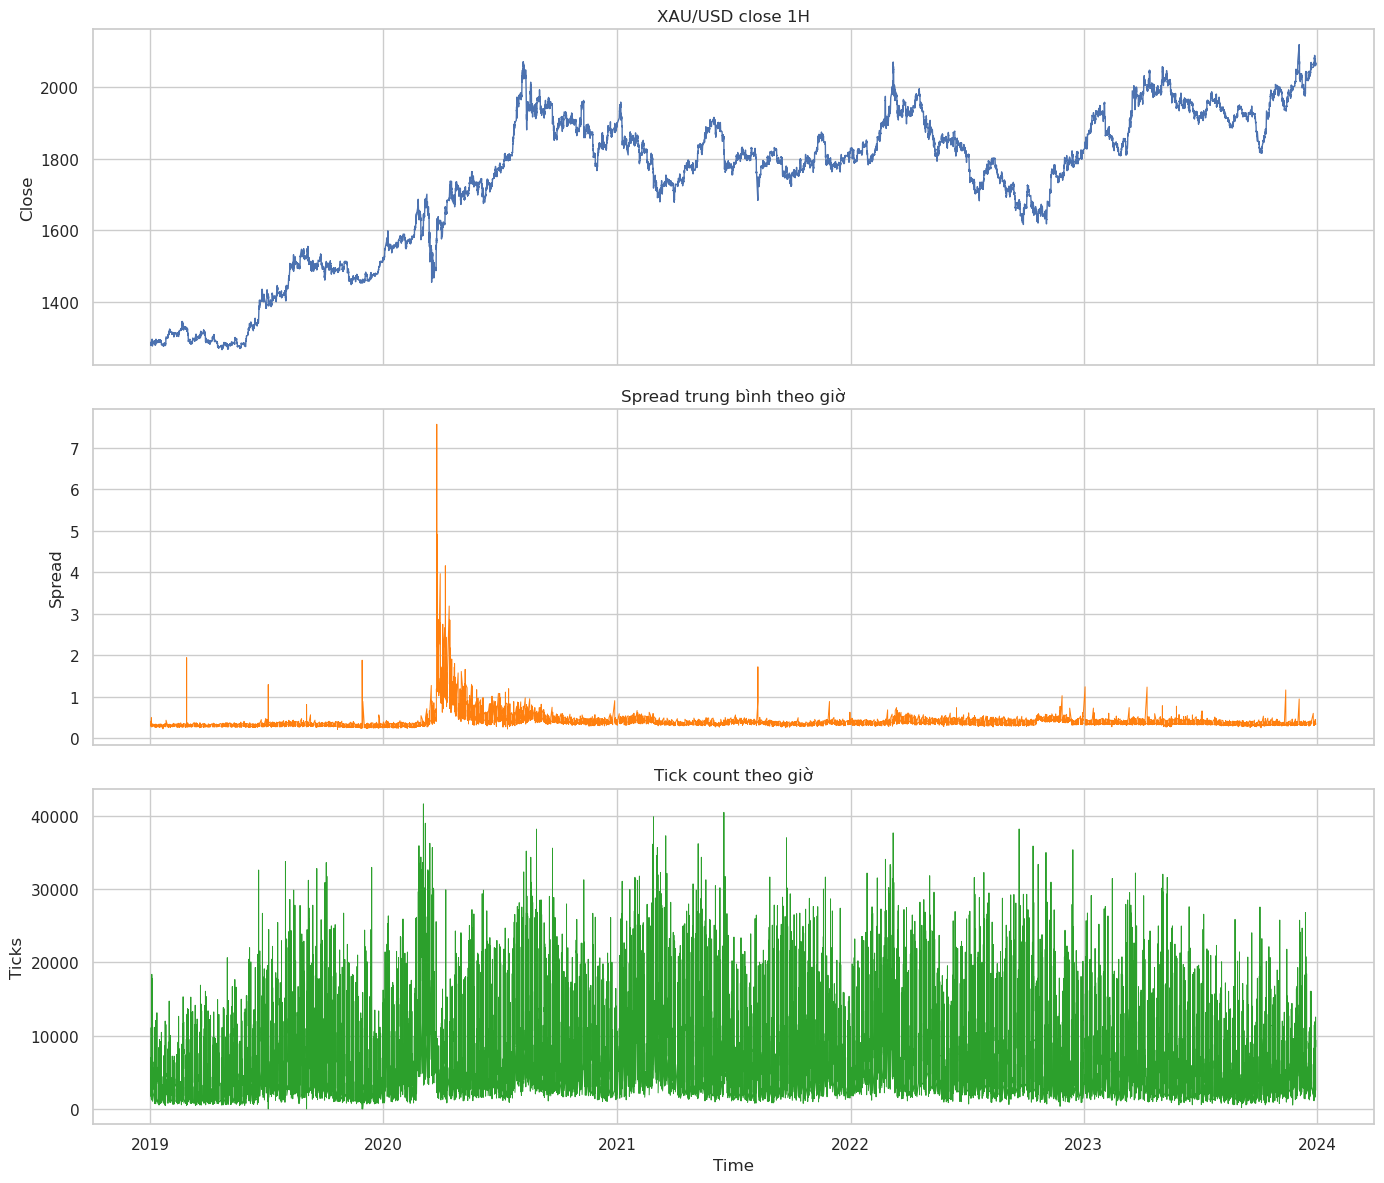

In [9]:
plot_df = candles.to_pandas()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
axes[0].plot(plot_df["timestamp"], plot_df["close"], linewidth=1)
axes[0].set_title("XAU/USD close 1H")
axes[0].set_ylabel("Close")

axes[1].plot(plot_df["timestamp"], plot_df["spread"], linewidth=0.7, color="tab:orange")
axes[1].set_title("Spread trung bình theo giờ")
axes[1].set_ylabel("Spread")

axes[2].plot(plot_df["timestamp"], plot_df["tick_count"], linewidth=0.7, color="tab:green")
axes[2].set_title("Tick count theo giờ")
axes[2].set_ylabel("Ticks")
axes[2].set_xlabel("Time")

plt.tight_layout()


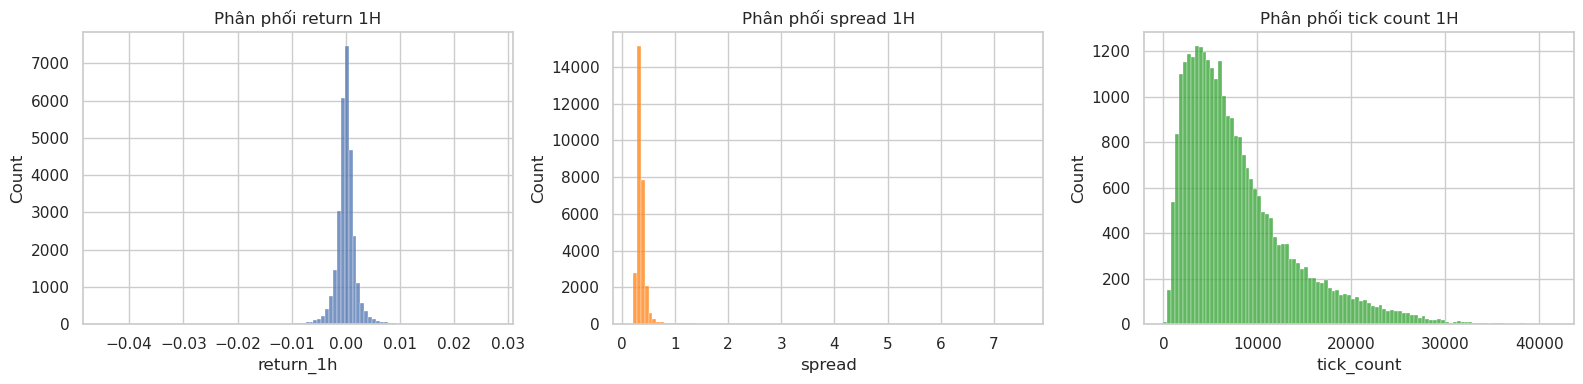

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(plot_df["return_1h"].dropna(), bins=100, ax=axes[0])
axes[0].set_title("Phân phối return 1H")

sns.histplot(plot_df["spread"], bins=100, ax=axes[1], color="tab:orange")
axes[1].set_title("Phân phối spread 1H")

sns.histplot(plot_df["tick_count"], bins=100, ax=axes[2], color="tab:green")
axes[2].set_title("Phân phối tick count 1H")

plt.tight_layout()


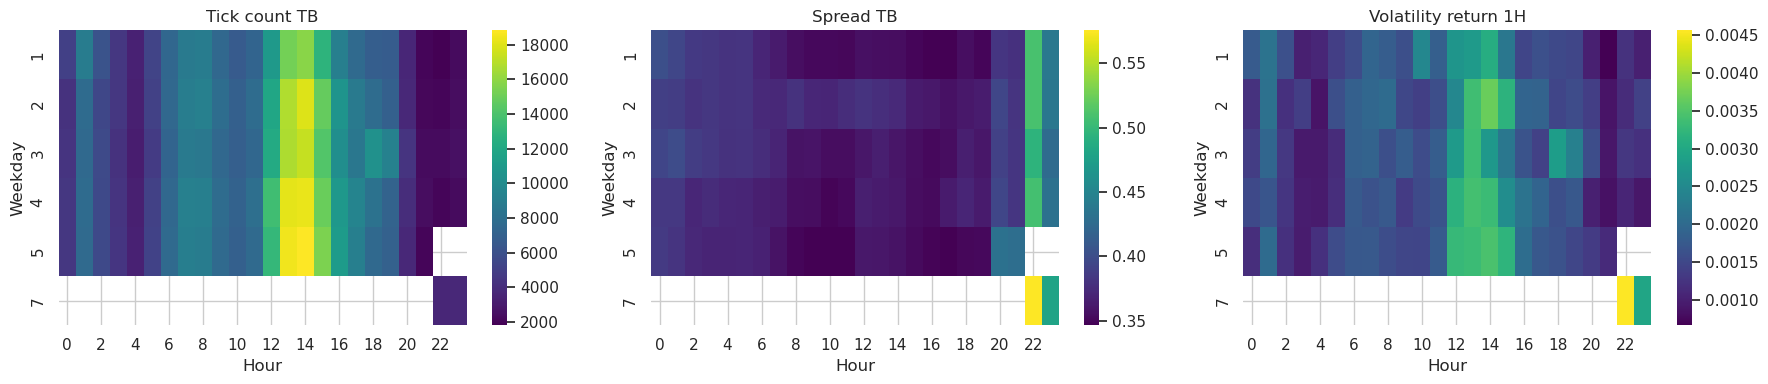

In [11]:
seasonality = (
    candles.with_columns(
        pl.col("timestamp").dt.hour().alias("hour"),
        pl.col("timestamp").dt.weekday().alias("weekday"),
    )
    .group_by(["weekday", "hour"])
    .agg(
        pl.col("tick_count").mean().alias("avg_tick_count"),
        pl.col("spread").mean().alias("avg_spread"),
        pl.col("return_1h").std().alias("return_vol"),
    )
    .sort(["weekday", "hour"])
)

seasonality_pd = seasonality.to_pandas()
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, value, title in zip(
    axes,
    ["avg_tick_count", "avg_spread", "return_vol"],
    ["Tick count TB", "Spread TB", "Volatility return 1H"],
):
    pivot = seasonality_pd.pivot(index="weekday", columns="hour", values=value)
    sns.heatmap(pivot, cmap="viridis", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Weekday")

plt.tight_layout()


## 6. Kiểm tra feature/label nhanh

Phần này dùng đúng pipeline feature và labeling để xem số mẫu còn lại sau khi loại giá trị warm-up/null và label neutral.

In [12]:
from src.config import PipelineConfig
from src.data.loader import apply_labels_to_frame
from src.features.engineering import combine_market_features

config = PipelineConfig(months=None)
featured = combine_market_features(candles.drop("return_1h"))
labeled = apply_labels_to_frame(
    featured,
    horizon=config.labeling_horizon,
    threshold=config.label_return_threshold,
    max_gap_hours=config.max_label_gap_hours,
)

label_counts = labeled.group_by("label").agg(pl.len().alias("rows")).sort("label")
ret_summary = labeled.select(
    pl.col("future_return").min().alias("min_future_return"),
    pl.col("future_return").quantile(0.01).alias("p01_future_return"),
    pl.col("future_return").median().alias("median_future_return"),
    pl.col("future_return").quantile(0.99).alias("p99_future_return"),
    pl.col("future_return").max().alias("max_future_return"),
)

print(f"Featured bars: {len(featured):,}")
print(f"Labeled rows: {len(labeled):,}")
display(label_counts)
display(ret_summary)


Featured bars: 29,550
Labeled rows: 23,485


label,rows
f64,u32
-1.0,11502
1.0,11983


min_future_return,p01_future_return,median_future_return,p99_future_return,max_future_return
f64,f64,f64,f64,f64
-0.054342,-0.011878,0.000554,0.011667,0.045772
